# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [2]:
# # --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

## Feature 1


In [4]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df['spend_income_ratio'] = df['monthly_spend'] / df['income']

# Correlation check
df[['spend_income_ratio', 'default_flag']].corr()

,spend_income_ratio,default_flag
spend_income_ratio,1.000000,-0.036101
default_flag,-0.036101,1.000000


### Rationale for Feature 1
spend income ratio can be good to see if there's any correlation btwn $ of income is spent monthly. Can see how that changes vs income, region etc. This data is showing almost no correlation

In [7]:
# TODO: Add another feature
df['rolling_spend_mean'] = df['monthly_spend'].rolling(3).mean()
df[['rolling_spend_mean', 'default_flag']].corr()

,rolling_spend_mean,default_flag
rolling_spend_mean,1.00000,-0.00978
default_flag,-0.00978,1.00000


### Rationale for Feature 2
Rolling spend mean is smoother and helps reduce short-term spending fluctuations, allowing you to analyize overall spending trends more effectively. Here, very weak negative correlation.

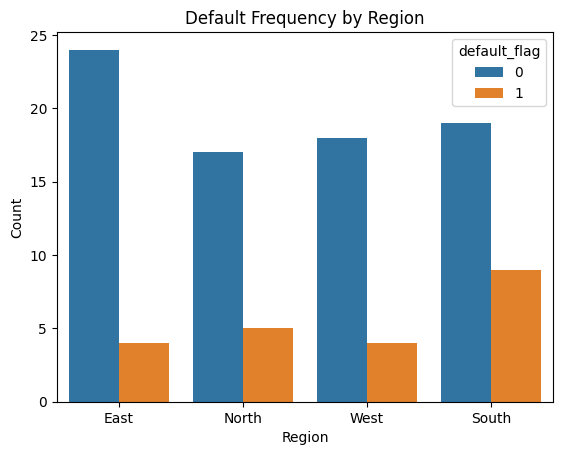

In [12]:
# TODO: Add a third feature. At least one of your three must ENCODE A CATEGORICAL
#   column - `region` is the one in this dataset.
#
#   The lecture shows three ways (section 'Categorical Encoding'):
#     one-hot     pd.get_dummies(df, columns=['region'])
#     label       LabelEncoder().fit_transform(df['region'])
df['region_frequency'] = df['region'].map(
    df['region'].value_counts(normalize=True)
)
#
#   Pick one and say WHY you picked it in the markdown cell below - the three are not
#   interchangeable, and that choice is the point of the exercise.
sns.countplot(data=df, x='region', hue='default_flag')
plt.title('Default Frequency by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

### Rationale for Feature 3
Chose frequency bc it converts each category into numerical value while keeping data in a single column. Showing that there may be some relationship with the south having more defaults, but not enough information.

In [14]:
# adding features from src:
from src.features import add_features

df = add_features(df)